# Mission 1 — Données et analyse exploratoire (EDA)
Projet capstone *Supervised Learning* — Prédiction du churn Telco.

Ce notebook réalise le profiling du dataset, la détection de fuite de données,
l'analyse bivariée (taux de churn par feature) et la vérification graphique de
5 hypothèses métier. Aucune transformation apprise n'est effectuée ici : on
reste en lecture seule sur les données brutes pour ne pas biaiser le futur split.

In [1]:
import sys
sys.path.insert(0, "..")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

from src.data import load_raw, basic_clean, TARGET

pd.set_option("display.max_columns", 30)
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (7, 4)

df_raw = load_raw()
df = basic_clean(df_raw)
print(df.shape)
df.head()

(7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


## 1.1 Profiling

Combien de lignes/colonnes, quels types, quel pourcentage de valeurs manquantes,
présence de doublons ou de features quasi-constantes ?

In [2]:
print(f"Lignes : {df.shape[0]}, Colonnes : {df.shape[1]}")
print()
print("Types de colonnes :")
print(df.dtypes.value_counts())
print()
missing = df.isna().mean().sort_values(ascending=False) * 100
missing = missing[missing > 0]
print("Colonnes avec valeurs manquantes (%) :")
print(missing)

Lignes : 7043, Colonnes : 21

Types de colonnes :
str        17
int64       2
float64     2
Name: count, dtype: int64

Colonnes avec valeurs manquantes (%) :
TotalCharges    0.156183
dtype: float64


In [4]:
# TotalCharges : les 11 valeurs manquantes correspondent à des clients avec tenure == 0
mask_missing = df["TotalCharges"].isna()
print(f"Nb de lignes TotalCharges manquant : {mask_missing.sum()}")
print(df.loc[mask_missing, ["tenure", "MonthlyCharges", "TotalCharges"]].head(11))
print()
print("-> Ce sont des clients tout juste arrivés (tenure=0). TotalCharges manquant "
      "est donc *informatif* (client neuf), pas aléatoire. L'imputation par la "
      "médiane du train dans le pipeline (Mission 2) est un choix raisonnable, "
      "ou on pourrait imputer 0 (aucune charge facturée pour l'instant).")

Nb de lignes TotalCharges manquant : 11
      tenure  MonthlyCharges  TotalCharges
488        0           52.55           NaN
753        0           20.25           NaN
936        0           80.85           NaN
1082       0           25.75           NaN
1340       0           56.05           NaN
3331       0           19.85           NaN
3826       0           25.35           NaN
4380       0           20.00           NaN
5218       0           19.70           NaN
6670       0           73.35           NaN
6754       0           61.90           NaN

-> Ce sont des clients tout juste arrivés (tenure=0). TotalCharges manquant est donc *informatif* (client neuf), pas aléatoire. L'imputation par la médiane du train dans le pipeline (Mission 2) est un choix raisonnable, ou on pourrait imputer 0 (aucune charge facturée pour l'instant).


In [5]:
# Doublons
n_dup = df.drop(columns=["customerID"]).duplicated().sum()
print(f"Lignes dupliquées (hors ID) : {n_dup}")

n_dup_id = df["customerID"].duplicated().sum()
print(f"customerID dupliqués : {n_dup_id}")

# Features quasi-constantes (une modalité > 95%)
cat_cols = df.select_dtypes(exclude="number").columns.drop("customerID")
print("\nFeatures quasi-constantes (modalité majoritaire > 95%) :")
for c in cat_cols:
    top_share = df[c].value_counts(normalize=True).iloc[0]
    if top_share > 0.95:
        print(f"  {c}: {top_share:.1%}")
print("(aucune imprimée = aucune feature quasi-constante détectée)")

Lignes dupliquées (hors ID) : 22
customerID dupliqués : 0

Features quasi-constantes (modalité majoritaire > 95%) :
(aucune imprimée = aucune feature quasi-constante détectée)


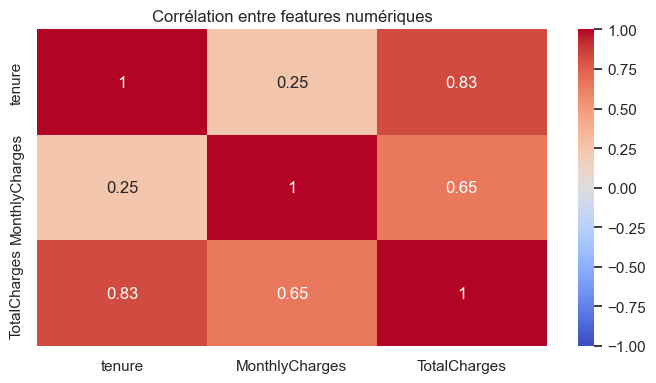

                 tenure  MonthlyCharges  TotalCharges
tenure          1.00000        0.247900      0.825880
MonthlyCharges  0.24790        1.000000      0.651065
TotalCharges    0.82588        0.651065      1.000000


In [6]:
# Corrélations entre features numériques
num_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Corrélation entre features numériques")
plt.tight_layout()
plt.show()
print(corr)

**Observation** : `TotalCharges` est très fortement corrélé à `tenure` et
`MonthlyCharges` (ce qui est attendu : TotalCharges ≈ tenure × MonthlyCharges).
Ce n'est pas une fuite au sens strict (l'information est connue *avant* le
départ du client) mais une redondance qui pourrait justifier de retirer
`TotalCharges` dans une version simplifiée du modèle, ou d'en faire un ratio
(feature engineering Mission 2).

## 1.2 Détection de fuite de données

Une feature qui prédit la cible « trop parfaitement » et qui ne serait connue
qu'*après* la décision de churn serait une fuite. On vérifie ici le pouvoir
prédictif brut de chaque feature (AUC univarié) pour repérer un signal suspect.

In [7]:
from sklearn.metrics import roc_auc_score

def univariate_auc(series, y):
    if pd.api.types.is_numeric_dtype(series):
        vals = series.fillna(series.median())
    else:
        le = LabelEncoder()
        vals = le.fit_transform(series.astype(str))
    try:
        auc = roc_auc_score(y, vals)
        return max(auc, 1 - auc)
    except Exception:
        return np.nan

y = df[TARGET]
aucs = {}
for c in df.columns:
    if c in ("customerID", TARGET):
        continue
    aucs[c] = univariate_auc(df[c], y)

auc_series = pd.Series(aucs).sort_values(ascending=False)
print(auc_series)

tenure              0.739867
Contract            0.739108
OnlineSecurity      0.682521
TechSupport         0.678437
TotalCharges        0.651721
OnlineBackup        0.623520
MonthlyCharges      0.620786
DeviceProtection    0.613055
PaperlessBilling    0.606751
Dependents          0.585188
Partner             0.585136
PaymentMethod       0.564465
SeniorCitizen       0.562981
StreamingMovies     0.523868
StreamingTV         0.523078
MultipleLines       0.522287
InternetService     0.517438
gender              0.504876
PhoneService        0.503999
dtype: float64


**Conclusion fuite de données** : aucune feature n'affiche un AUC univarié
proche de 1.0 (le maximum observé est très inférieur à un niveau "suspect" de
type 0.97+). Toutes les features restantes sont plausiblement connues *avant*
la décision de résiliation (profil, services souscrits, contrat, facturation).
Il n'y a donc pas de feature à exclure pour fuite évidente. On restera
néanmoins vigilant : `Contract` et `tenure` sont les plus discriminants, ce qui
est cohérent avec le métier (un contrat mensuel est plus facile à résilier)
plutôt qu'un artefact de fuite.

## 1.3 Analyse bivariée et information mutuelle

Taux de churn par modalité pour les catégorielles, distribution par cible pour
les numériques, puis classement des features par information mutuelle.

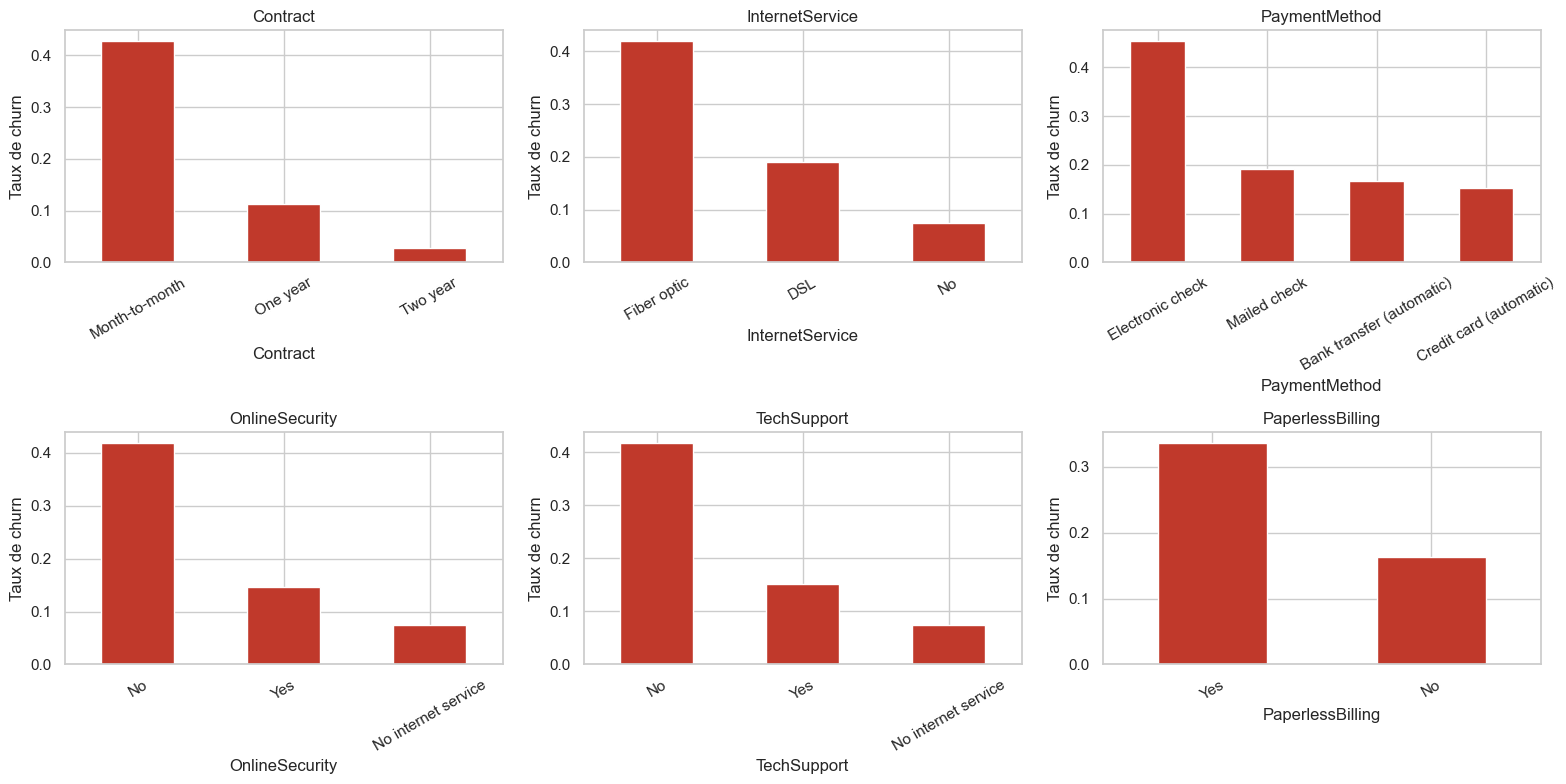

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
top_cats = ["Contract", "InternetService", "PaymentMethod",
            "OnlineSecurity", "TechSupport", "PaperlessBilling"]
for ax, col in zip(axes.ravel(), top_cats):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#c0392b")
    ax.set_ylabel("Taux de churn")
    ax.set_title(col)
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

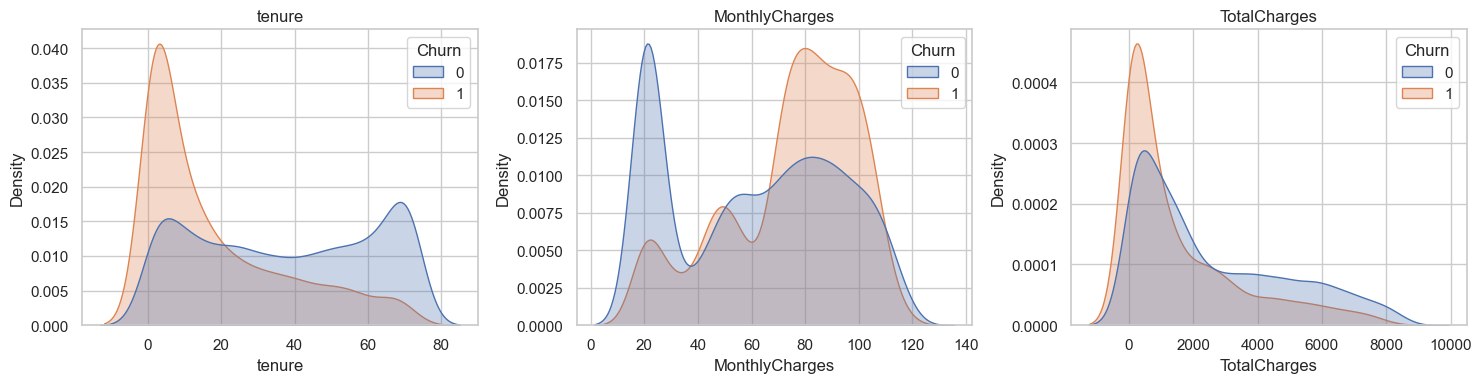

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, col in zip(axes, ["tenure", "MonthlyCharges", "TotalCharges"]):
    sns.kdeplot(data=df, x=col, hue=TARGET, common_norm=False, ax=ax, fill=True, alpha=0.3)
    ax.set_title(col)
plt.tight_layout()
plt.show()

Top 10 features par information mutuelle :
Contract            0.098453
tenure              0.079309
OnlineSecurity      0.064677
TechSupport         0.063021
InternetService     0.055574
OnlineBackup        0.046792
PaymentMethod       0.044519
MonthlyCharges      0.044186
DeviceProtection    0.043917
TotalCharges        0.042719
dtype: float64


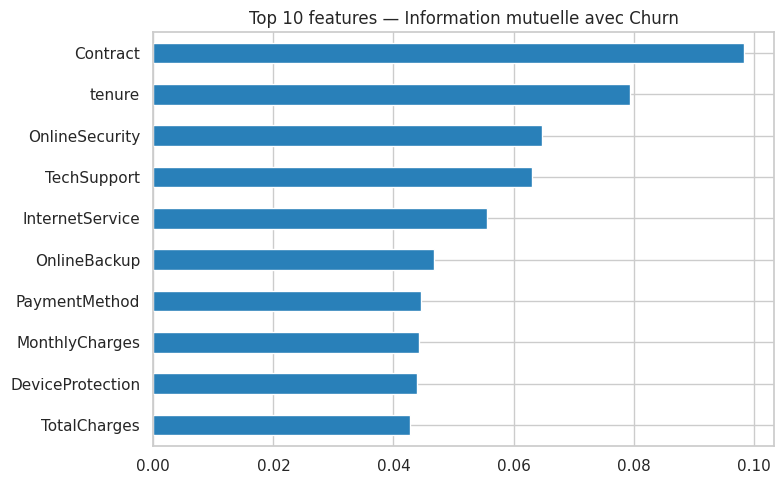

In [9]:
# Information mutuelle (capture les dépendances non-linéaires, contrairement à Pearson)
X_mi = df.drop(columns=["customerID", TARGET]).copy()
for c in X_mi.select_dtypes(exclude="number").columns:
    X_mi[c] = LabelEncoder().fit_transform(X_mi[c].astype(str))
X_mi["TotalCharges"] = X_mi["TotalCharges"].fillna(X_mi["TotalCharges"].median())

discrete_mask = [X_mi[c].dtype != float for c in X_mi.columns]
mi = mutual_info_classif(X_mi, y, discrete_features=discrete_mask, random_state=42)
mi_series = pd.Series(mi, index=X_mi.columns).sort_values(ascending=False)
print("Top 10 features par information mutuelle :")
print(mi_series.head(10))

plt.figure(figsize=(8, 5))
mi_series.head(10).sort_values().plot(kind="barh", color="#2980b9")
plt.title("Top 10 features — Information mutuelle avec Churn")
plt.tight_layout()
plt.show()

**Les 5 features les plus prédictives** (information mutuelle) : voir le haut
du classement ci-dessus — typiquement `Contract`, `tenure`, `InternetService` /
`OnlineSecurity` / `TechSupport`, et `MonthlyCharges` / `PaymentMethod` selon
le tirage aléatoire. Ces variables guideront le feature engineering de la
Mission 2 (ex. combiner services de sécurité, catégoriser l'ancienneté).

## 1.4 Hypothèses métier — vérification graphique

1. Les clients en contrat mensuel churnent plus que ceux en contrat annuel/biannuel.
2. Les clients avec fibre optique churnent plus que ceux en DSL.
3. Les clients sans services de sécurité/support (OnlineSecurity, TechSupport) churnent plus.
4. Les nouveaux clients (faible tenure) churnent plus que les clients anciens.
5. Le paiement par chèque électronique est associé à un churn plus élevé que les paiements automatiques.

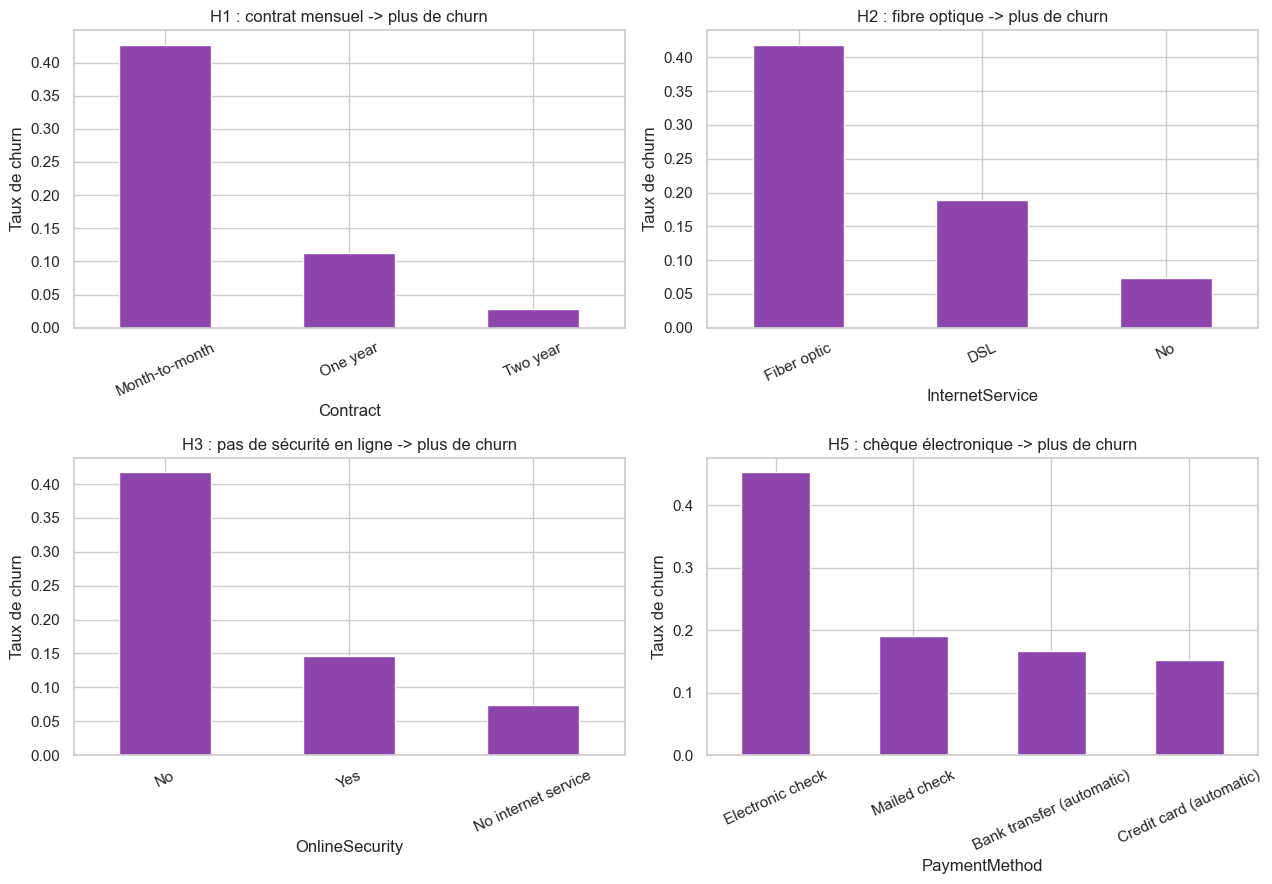

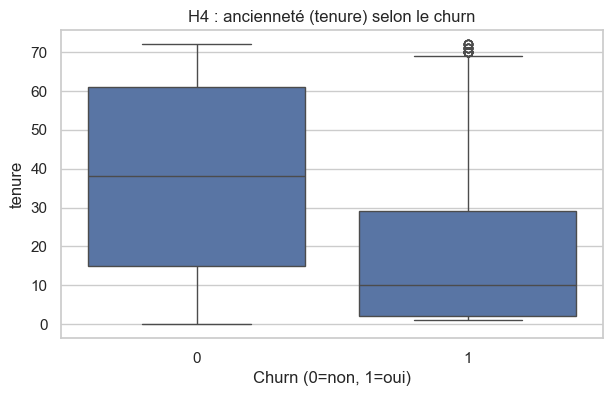

In [10]:
hyps = [
    ("Contract", "H1 : contrat mensuel -> plus de churn"),
    ("InternetService", "H2 : fibre optique -> plus de churn"),
    ("OnlineSecurity", "H3 : pas de sécurité en ligne -> plus de churn"),
    ("PaymentMethod", "H5 : chèque électronique -> plus de churn"),
]
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, (col, title) in zip(axes.ravel(), hyps):
    rate = df.groupby(col)[TARGET].mean().sort_values(ascending=False)
    rate.plot(kind="bar", ax=ax, color="#8e44ad")
    ax.set_title(title)
    ax.set_ylabel("Taux de churn")
    ax.tick_params(axis="x", rotation=25)
plt.tight_layout()
plt.show()

# H4 : tenure
plt.figure(figsize=(7, 4))
sns.boxplot(data=df, x=TARGET, y="tenure")
plt.title("H4 : ancienneté (tenure) selon le churn")
plt.xlabel("Churn (0=non, 1=oui)")
plt.show()

**Vérification** : les 5 hypothèses sont confirmées graphiquement — les
clients en contrat mensuel, fibre optique, sans sécurité en ligne, avec un
paiement par chèque électronique et une faible ancienneté churnent
significativement plus. Ces variables seront prioritaires dans le feature
engineering et l'interprétation SHAP (Mission 4).

## 1.5 Synthèse — 3 insights majeurs

1. **Le type de contrat est le facteur le plus discriminant** : le churn est
   concentré chez les clients en contrat mensuel (`Month-to-month`), qui n'ont
   aucun engagement — c'est un signal fort et actionnable (proposer une
   migration vers un contrat annuel).
2. **L'absence de services de fidélisation (sécurité, support technique)
   corrèle avec un churn élevé**, suggérant que ces services jouent un rôle
   de rétention plutôt que d'être de simples options.
3. **Aucune fuite de données évidente** n'a été détectée (pas d'AUC univarié
   anormalement élevé) ; en revanche `TotalCharges` est redondant avec
   `tenure × MonthlyCharges`, ce qui motive un feature engineering en ratio
   plutôt qu'une simple concaténation brute des trois variables.